# Predicting Airbnb Listing Prices in Melbourne, Australia

### Project Scope and Authorship

This notebook is an independent post-course rebuild of a Melbourne Airbnb price-prediction project originally completed as a university group assignment. In the original project, my assessed responsibility covered numerical-data cleaning, feature engineering, missing-value treatment and categorical encoding.

All model development presented in this notebook, including the validation strategy, baseline comparison, Ridge Regression, Random Forest, Gradient Boosting, hyperparameter tuning, outlier analysis and feature-importance analysis was completed independently after the course. The original group notebook and my teammates’ work are not reproduced or presented as my individual contribution.

The competition datasets are used only within this private working environment and will not be redistributed through the public GitHub repository.

---

## Business Problem and Initial Data Audit

### Business Objective

The objective is to predict the nightly price of Airbnb listings in Melbourne using listing capacity, location, property characteristics, host information, availability and review history. A reliable estimate could help hosts benchmark proposed prices against comparable listings and help marketplace analysts identify listings whose prices differ substantially from expected market patterns. The output should be treated as decision support rather than an automatic pricing rule, particularly for unusual or luxury properties.

### Analytical Framing

This is a supervised regression problem rather than a time-series forecasting problem. Each row represents a listing, and the model learns the relationship between its available characteristics and its recorded nightly price. The supplied data contain 7,000 labelled training records, 3,000 unlabelled competition records and 60 original predictors. The data originates from the [ASBA Predictive Analytics Competition](https://www.kaggle.com/competitions/asba-predictive-analytics-competition/data).

### Evaluation Metric

Model performance is evaluated using mean absolute error (MAE), which measures the average absolute difference between predicted and actual prices:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

MAE is expressed in the same currency as the target, making it straightforward to explain as the model’s average dollar error. It treats overpricing and underpricing errors equally and is less sensitive to large errors than squared-error measures such as RMSE. However, unusually expensive listings can still dominate the score, and the same dollar error has different practical significance for inexpensive and expensive properties. For this reason, overall MAE is reported alongside price-band sensitivity results.

In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
metadata = pd.read_csv("../data/metaData.csv")
sample_submission = pd.read_csv("../data/sample-solution.csv")

print("Training data:", train.shape)
print("Test data:", test.shape)
print("Metadata:", metadata.shape)
print("Sample submission:", sample_submission.shape)
print("Target present:", "price" in train.columns)
print("Target absent from test:", "price" not in test.columns)

Training data: (7000, 61)
Test data: (3000, 60)
Metadata: (62, 3)
Sample submission: (3000, 2)
Target present: True
Target absent from test: True


---

## Data Cleaning and Feature Engineering

### Preparation Approach

The preparation process was designed to make the analysis reproducible while preventing information from the validation and competition datasets from influencing model training.

| Area                               | Treatment and rationale                                                                                                                                                          |
| ---------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Price                              | Removed currency symbols and thousands separators, then converted the target to a numeric field.                                                                                 |
| Percentage fields                  | Converted host response and acceptance rates from percentage text into decimal values between 0 and 1.                                                                           |
| Bathrooms                          | Extracted numeric quantities and converted textual half-bath values to 0.5. Missing values were retained for pipeline imputation rather than treated as zero.                    |
| Dates                              | Converted host and review dates into numeric age and recency features using the fixed reference date 24 March 2023. This avoids results changing whenever the notebook is rerun. |
| Amenities and verification methods | Safely parsed stored lists with `ast.literal_eval` and counted their actual items. This replaces unsafe `eval()` usage and avoids counting characters in list strings.           |
| Descriptive text                   | Replaced high-cardinality free text with word-count features for descriptions, neighbourhood overviews and host profiles.                                                        |
| Boolean fields                     | Converted `t` and `f` values to 1 and 0.                                                                                                                                         |
| Missing numeric values             | Used training-data medians and added missingness indicators.                                                                                                                     |
| Missing categorical values         | Used the most frequent training category.                                                                                                                                        |
| Categorical encoding               | Retained up to five frequent categories plus an infrequent/other category and safely handled unseen values.                                                                      |
| Excluded fields                    | Removed IDs, names, detailed free text, raw list fields and original dates from modelling after creating suitable derived features.                                              |

The labelled data were divided into training and validation sets before any medians or categorical mappings were learned. All preprocessing was included inside each model pipeline so it was refitted independently within every cross-validation fold.


### 2.1 Cleaning Numeric Features

In [3]:
# Preserve the original data
train_clean = train.copy()
test_clean = test.copy()

# Convert price from currency-formatted text to numeric
train_clean["price"] = pd.to_numeric(
    train_clean["price"]
        .astype("string")
        .str.replace(r"[$,]", "", regex=True)
        .str.strip(),
    errors="coerce"
)

print(train_clean["price"].describe())
print("\nMissing after conversion:", train_clean["price"].isna().sum())
print("Non-positive prices:", (train_clean["price"] <= 0).sum())
print("Prices above $2,000:", (train_clean["price"] > 2000).sum())

count         7000.0
mean      285.649714
std      2325.453324
min             25.0
25%            117.0
50%            172.0
75%            268.0
max         145160.0
Name: price, dtype: Float64

Missing after conversion: 0
Non-positive prices: 0
Prices above $2,000: 26


In [4]:
audit_columns = [
    column for column in [
        "id",
        "price",
        "property_type",
        "room_type",
        "accommodates",
        "bedrooms",
        "bathrooms",
        "minimum_nights",
        "neighbourhood_cleansed"
    ]
    if column in train_clean.columns
]

display(
    train_clean
        .nlargest(15, "price")[audit_columns]
        .reset_index(drop=True)
)

,price,property_type,room_type,accommodates,bedrooms,bathrooms,minimum_nights,neighbourhood_cleansed
0,145160.0,Entire rental unit,Entire home/apt,2,NaN,1 bath,2,Melbourne
1,104983.0,Private room in villa,Private room,2,1.0,1 shared bath,70,Boroondara
2,55419.0,Entire guesthouse,Entire home/apt,3,NaN,1 bath,2,Yarra
3,40844.0,Entire rental unit,Entire home/apt,4,NaN,1 bath,2,Melbourne
4,17988.0,Entire rental unit,Entire home/apt,4,2.0,2 baths,3,Port Phillip
5,16429.0,Entire rental unit,Entire home/apt,2,1.0,1 bath,1,Melbourne
6,9999.0,Entire rental unit,Entire home/apt,5,NaN,1 bath,1,Melbourne
7,9999.0,Entire home,Entire home/apt,6,3.0,1 bath,2,Knox
8,8499.0,Entire rental unit,Entire home/apt,5,2.0,1 bath,1,Melbourne
9,5750.0,Private room in rental unit,Private room,2,1.0,1 shared bath,1,Melbourne


In [5]:
def clean_percentage(series):
    return pd.to_numeric(
        series.astype("string").str.extract(r"(\d+(?:\.\d+)?)")[0],
        errors="coerce"
    ) / 100


def clean_bathrooms(series):
    text = series.astype("string").str.lower()

    values = pd.to_numeric(
        text.str.extract(r"(\d+(?:\.\d+)?)")[0],
        errors="coerce"
    )

    # Convert textual half-bath values
    values = values.mask(
        text.str.contains("half-bath", na=False) & values.isna(),
        0.5
    )

    return values


for dataset in [train_clean, test_clean]:
    dataset["host_response_rate"] = clean_percentage(
        dataset["host_response_rate"]
    )
    dataset["host_acceptance_rate"] = clean_percentage(
        dataset["host_acceptance_rate"]
    )
    dataset["bathrooms"] = clean_bathrooms(dataset["bathrooms"])


print(
    train_clean[
        ["host_response_rate", "host_acceptance_rate", "bathrooms"]
    ].describe()
)

print(
    "\nMissing values:\n",
    train_clean[
        ["host_response_rate", "host_acceptance_rate", "bathrooms"]
    ].isna().sum()
)

       host_response_rate  host_acceptance_rate  bathrooms
count              7000.0                6937.0     6994.0
mean             0.960096              0.885363    1.37525
std               0.13795              0.205724   0.687044
min                   0.0                   0.0        0.0
25%                   1.0                  0.89        1.0
50%                   1.0                  0.97        1.0
75%                   1.0                   1.0        2.0
max                   1.0                   1.0       10.0

Missing values:
 host_response_rate       0
host_acceptance_rate    63
bathrooms                6
dtype: int64


### 2.2 Feature Engineering

In [6]:
# Fixed reference date: one day after the latest review in the training data
REFERENCE_DATE = pd.Timestamp("2023-03-24")

for dataset in [train_clean, test_clean]:
    for column in ["host_since", "first_review", "last_review"]:
        dataset[column] = pd.to_datetime(
            dataset[column],
            errors="coerce"
        )

    dataset["host_tenure_days"] = (
        REFERENCE_DATE - dataset["host_since"]
    ).dt.days

    dataset["listing_review_age_days"] = (
        REFERENCE_DATE - dataset["first_review"]
    ).dt.days

    dataset["days_since_last_review"] = (
        REFERENCE_DATE - dataset["last_review"]
    ).dt.days


date_features = [
    "host_tenure_days",
    "listing_review_age_days",
    "days_since_last_review"
]

print(train_clean[date_features].describe())
print("\nMissing values:\n", train_clean[date_features].isna().sum())
print("\nNegative values:\n", (train_clean[date_features] < 0).sum())

       host_tenure_days  listing_review_age_days  days_since_last_review
count       7000.000000              7000.000000             7000.000000
mean        2531.158714              1482.814143              196.114000
std          901.364123               859.433165              409.935279
min          443.000000                18.000000                1.000000
25%         1929.000000               736.000000               24.000000
50%         2587.000000              1404.500000               40.000000
75%         3145.000000              2096.250000              110.000000
max         5132.000000              4579.000000             4074.000000

Missing values:
 host_tenure_days           0
listing_review_age_days    0
days_since_last_review     0
dtype: int64

Negative values:
 host_tenure_days           0
listing_review_age_days    0
days_since_last_review     0
dtype: int64


In [7]:
import ast

def count_list_items(value):
    if pd.isna(value):
        return np.nan

    try:
        parsed_value = ast.literal_eval(value)
    except (ValueError, SyntaxError, TypeError):
        return np.nan

    if isinstance(parsed_value, (list, tuple, set)):
        return len(parsed_value)

    return np.nan


for dataset in [train_clean, test_clean]:
    dataset["amenities_count"] = dataset["amenities"].apply(
        count_list_items
    )
    dataset["verification_count"] = dataset["host_verifications"].apply(
        count_list_items
    )


count_features = ["amenities_count", "verification_count"]

print(train_clean[count_features].describe())
print("\nMissing values:\n", train_clean[count_features].isna().sum())

       amenities_count  verification_count
count      7000.000000         7000.000000
mean         36.130143            2.181714
std          14.438524            0.499015
min           0.000000            1.000000
25%          26.000000            2.000000
50%          35.000000            2.000000
75%          46.000000            2.000000
max         117.000000            3.000000

Missing values:
 amenities_count       0
verification_count    0
dtype: int64


In [8]:
text_columns = [
    "description",
    "neighborhood_overview",
    "host_about"
]

for dataset in [train_clean, test_clean]:
    for column in text_columns:
        new_column = f"{column}_word_count"

        dataset[new_column] = (
            dataset[column]
                .fillna("")
                .astype(str)
                .str.split()
                .str.len()
        )


text_features = [
    "description_word_count",
    "neighborhood_overview_word_count",
    "host_about_word_count"
]

print(train_clean[text_features].describe())
print("\nMissing values:\n", train_clean[text_features].isna().sum())

       description_word_count  neighborhood_overview_word_count  \
count             7000.000000                       7000.000000   
mean               138.208571                         49.562857   
std                 41.138577                         50.701602   
min                  0.000000                          0.000000   
25%                127.000000                          0.000000   
50%                156.000000                         37.000000   
75%                164.000000                         77.000000   
max                197.000000                        223.000000   

       host_about_word_count  
count            7000.000000  
mean               58.727286  
std                87.130213  
min                 0.000000  
25%                 0.000000  
50%                31.000000  
75%                84.000000  
max               905.000000  

Missing values:
 description_word_count              0
neighborhood_overview_word_count    0
host_about_word_count  

### 2.3 Categorical Encoding

In [9]:
boolean_columns = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "has_availability",
    "instant_bookable"
]

boolean_mapping = {
    "t": 1,
    "f": 0
}

for dataset in [train_clean, test_clean]:
    for column in boolean_columns:
        dataset[column] = dataset[column].map(boolean_mapping)


for column in boolean_columns:
    print(
        column,
        train_clean[column].value_counts(dropna=False).to_dict()
    )


host_is_superhost {0: 3981, 1: 3019}
host_has_profile_pic {1: 6985, 0: 15}
host_identity_verified {1: 6700, 0: 300}
has_availability {1: 7000}
instant_bookable {0: 5287, 1: 1713}


### 2.4 Validation Strategy

In [10]:
from sklearn.model_selection import train_test_split


# Exclude identifiers, sensitive/high-cardinality text, and original
# fields already represented by engineered numeric features
excluded_features = [
    "ID",
    "name",
    "description",
    "neighborhood_overview",
    "host_name",
    "host_location",
    "host_about",
    "host_neighbourhood",
    "neighbourhood",
    "amenities",
    "host_verifications",
    "host_since",
    "first_review",
    "last_review"
]

competition_test_ids = test_clean["ID"].copy()

X = train_clean.drop(
    columns=excluded_features + ["price"],
    errors="ignore"
)

y = train_clean["price"].astype(float)

X_competition_test = test_clean.drop(
    columns=excluded_features,
    errors="ignore"
)

assert list(X.columns) == list(X_competition_test.columns)

# Preserve approximately similar price distributions in both sets
price_strata = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates="drop"
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=price_strata
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("Competition test:", X_competition_test.shape)

print("\nTraining median price:", y_train.median())
print("Validation median price:", y_valid.median())
print("Training maximum price:", y_train.max())
print("Validation maximum price:", y_valid.max())
print("Training prices above $2,000:", (y_train > 2000).sum())
print("Validation prices above $2,000:", (y_valid > 2000).sum())

X_train: (5600, 54)
X_valid: (1400, 54)
Competition test: (3000, 54)

Training median price: 172.0
Validation median price: 172.0
Training maximum price: 145160.0
Validation maximum price: 104983.0
Training prices above $2,000: 20
Validation prices above $2,000: 6


### 2.5 Missing-Value Treatment

In [11]:
missing_summary = (
    X_train.isna()
        .sum()
        .rename("missing_count")
        .to_frame()
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(X_train) * 100
).round(2)

missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values("missing_percentage", ascending=False)
)

print("Numeric features:", X_train.select_dtypes(
    include=np.number
).shape[1])

print("Categorical features:", X_train.select_dtypes(
    exclude=np.number
).shape[1])

display(missing_summary)

Numeric features: 49
Categorical features: 5


,missing_count,missing_percentage
bedrooms,297,5.30
room_type,109,1.95
neighbourhood_cleansed,88,1.57
property_type,61,1.09
beds,56,1.00
host_acceptance_rate,52,0.93
availability_365,39,0.70
minimum_minimum_nights,32,0.57
maximum_maximum_nights,32,0.57
review_scores_checkin,18,0.32


### 2.6 Preprocessing Pipeline

In [12]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()


numeric_preprocessor = SimpleImputer(
    strategy="median",
    add_indicator=True
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                max_categories=6,
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_preprocessor,
            numeric_features
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_features
        )
    ]
)


# Temporary validation check; models will later contain their own
# copy of this preprocessor to prevent cross-validation leakage
preprocessor_check = clone(preprocessor)

X_train_check = preprocessor_check.fit_transform(X_train)
X_valid_check = preprocessor_check.transform(X_valid)

print("Processed training shape:", X_train_check.shape)
print("Processed validation shape:", X_valid_check.shape)
print("Training missing values:", np.isnan(X_train_check).sum())
print("Validation missing values:", np.isnan(X_valid_check).sum())

Processed training shape: (5600, 84)
Processed validation shape: (1400, 84)
Training missing values: 0
Validation missing values: 0


## Exploratory Data Analysis

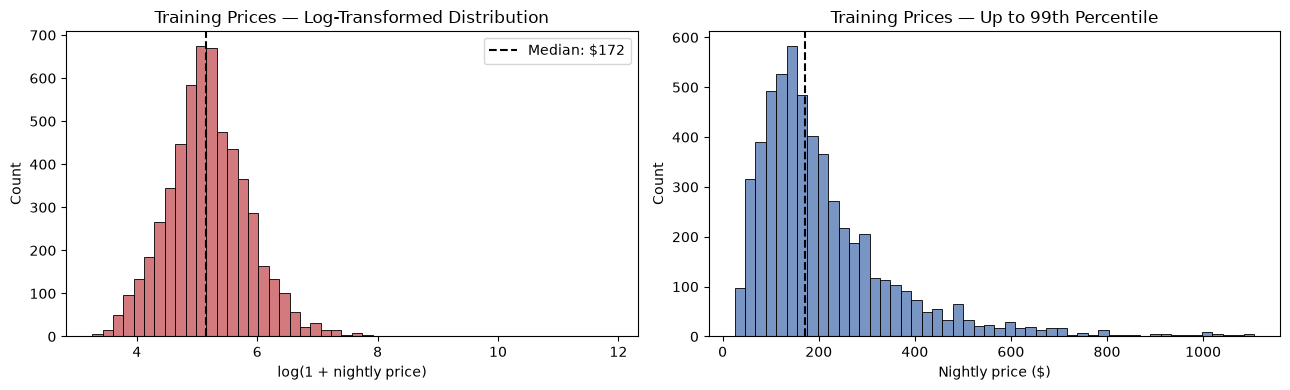

Price skewness: 56.59
95th percentile: $555.00
99th percentile: $1,106.01


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns


training_price_99 = y_train.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

log_training_prices = np.log1p(y_train)

sns.histplot(
    log_training_prices,
    bins=50,
    color="#C44E52",
    ax=axes[0]
)

axes[0].axvline(
    np.log1p(y_train.median()),
    color="black",
    linestyle="--",
    label=f"Median: ${y_train.median():,.0f}"
)

axes[0].set_title("Training Prices — Log-Transformed Distribution")
axes[0].set_xlabel("log(1 + nightly price)")
axes[0].legend()

sns.histplot(
    y_train[y_train <= training_price_99],
    bins=50,
    color="#4C72B0",
    ax=axes[1]
)

axes[1].axvline(
    y_train.median(),
    color="black",
    linestyle="--"
)
axes[1].set_title("Training Prices — Up to 99th Percentile")
axes[1].set_xlabel("Nightly price ($)")

plt.tight_layout()
plt.savefig(
    "../images/price_distribution.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print(f"Price skewness: {y_train.skew():.2f}")
print(f"95th percentile: ${y_train.quantile(0.95):,.2f}")
print(f"99th percentile: ${training_price_99:,.2f}")

Training prices are strongly right-skewed, with a skewness of 56.59. Although 95% of listings are priced at or below $555 and 99% are at or below approximately $1,106, a small number of extremely high prices extend the distribution substantially. Applying a logarithmic transformation produces a more compact distribution for modelling, but all evaluation results will remain on the original dollar scale using mean absolute error. Extreme observations are retained initially because the available data cannot confirm whether they are errors; their effect will be assessed separately through sensitivity analysis.

--- 
## Model Development and Evaluation


### 3.1 Median Baseline

In [14]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error


baseline_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", DummyRegressor(strategy="median"))
    ]
)

baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_valid)

absolute_errors = np.abs(
    y_valid.to_numpy() - baseline_predictions
)

extreme_mask = y_valid.to_numpy() > 2000

baseline_mae = mean_absolute_error(
    y_valid,
    baseline_predictions
)

baseline_median_error = median_absolute_error(
    y_valid,
    baseline_predictions
)

regular_listing_mae = mean_absolute_error(
    y_valid.to_numpy()[~extreme_mask],
    baseline_predictions[~extreme_mask]
)

extreme_error_share = (
    absolute_errors[extreme_mask].sum()
    / absolute_errors.sum()
    * 100
)

print(f"Overall validation MAE: ${baseline_mae:,.2f}")
print(f"Median absolute error: ${baseline_median_error:,.2f}")
print(f"MAE for prices up to $2,000: ${regular_listing_mae:,.2f}")
print(f"Share of error from 6 extreme listings: {extreme_error_share:.2f}%")

Overall validation MAE: $198.88
Median absolute error: $68.50
MAE for prices up to $2,000: $105.13
Share of error from 6 extreme listings: 47.36%


### 3.2 Log-Target Ridge Regression

In [15]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler


linear_numeric_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            linear_numeric_preprocessor,
            numeric_features
        ),
        (
            "categorical",
            clone(categorical_preprocessor),
            categorical_features
        )
    ]
)

ridge_model = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            TransformedTargetRegressor(
                regressor=Ridge(alpha=10.0),
                func=np.log1p,
                inverse_func=np.expm1
            )
        )
    ]
)

ridge_model.fit(X_train, y_train)

ridge_predictions = np.maximum(
    ridge_model.predict(X_valid),
    0
)

ridge_mae = mean_absolute_error(
    y_valid,
    ridge_predictions
)

ridge_regular_mae = mean_absolute_error(
    y_valid.to_numpy()[~extreme_mask],
    ridge_predictions[~extreme_mask]
)

ridge_improvement = (
    (baseline_mae - ridge_mae)
    / baseline_mae
    * 100
)

print(f"Ridge overall MAE: ${ridge_mae:,.2f}")
print(f"Ridge MAE up to $2,000: ${ridge_regular_mae:,.2f}")
print(f"Improvement over baseline: {ridge_improvement:.2f}%")

Ridge overall MAE: $159.30
Ridge MAE up to $2,000: $65.99
Improvement over baseline: 19.90%


### 3.3 Log-Target Random Forest

In [16]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "model",
            TransformedTargetRegressor(
                regressor=RandomForestRegressor(
                    n_estimators=400,
                    min_samples_leaf=2,
                    max_features=0.7,
                    random_state=42,
                    n_jobs=-1
                ),
                func=np.log1p,
                inverse_func=np.expm1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = np.maximum(
    random_forest_model.predict(X_valid),
    0
)

random_forest_mae = mean_absolute_error(
    y_valid,
    random_forest_predictions
)

random_forest_regular_mae = mean_absolute_error(
    y_valid.to_numpy()[~extreme_mask],
    random_forest_predictions[~extreme_mask]
)

baseline_improvement = (
    (baseline_mae - random_forest_mae)
    / baseline_mae
    * 100
)

ridge_difference = ridge_mae - random_forest_mae

print(f"Random Forest overall MAE: ${random_forest_mae:,.2f}")
print(
    f"Random Forest MAE up to $2,000: "
    f"${random_forest_regular_mae:,.2f}"
)
print(f"Improvement over baseline: {baseline_improvement:.2f}%")
print(
    f"MAE difference compared with Ridge: "
    f"${ridge_difference:,.2f}"
)

Random Forest overall MAE: $150.20
Random Forest MAE up to $2,000: $57.05
Improvement over baseline: 24.48%
MAE difference compared with Ridge: $9.10


### 3.4 Log-Target Gradient Boosting

In [17]:
from sklearn.ensemble import HistGradientBoostingRegressor


gradient_boosting_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "model",
            TransformedTargetRegressor(
                regressor=HistGradientBoostingRegressor(
                    loss="absolute_error",
                    learning_rate=0.05,
                    max_iter=400,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=1.0,
                    random_state=42
                ),
                func=np.log1p,
                inverse_func=np.expm1
            )
        )
    ]
)

gradient_boosting_model.fit(X_train, y_train)

gradient_boosting_predictions = np.maximum(
    gradient_boosting_model.predict(X_valid),
    0
)

gradient_boosting_mae = mean_absolute_error(
    y_valid,
    gradient_boosting_predictions
)

gradient_boosting_regular_mae = mean_absolute_error(
    y_valid.to_numpy()[~extreme_mask],
    gradient_boosting_predictions[~extreme_mask]
)

baseline_improvement = (
    (baseline_mae - gradient_boosting_mae)
    / baseline_mae
    * 100
)

print(
    f"Gradient Boosting overall MAE: "
    f"${gradient_boosting_mae:,.2f}"
)
print(
    f"Gradient Boosting MAE up to $2,000: "
    f"${gradient_boosting_regular_mae:,.2f}"
)
print(f"Improvement over baseline: {baseline_improvement:.2f}%")
print(
    f"Difference compared with Random Forest: "
    f"${random_forest_mae - gradient_boosting_mae:,.2f}"
)

Gradient Boosting overall MAE: $144.53
Gradient Boosting MAE up to $2,000: $51.25
Improvement over baseline: 27.33%
Difference compared with Random Forest: $5.67


### 3.5 Cross-Validation Comparison

In [18]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)


# Price bands distribute very expensive listings across folds
cv_price_bands = pd.cut(
    y_train,
    bins=[
        -np.inf,
        100,
        150,
        200,
        300,
        500,
        1000,
        2000,
        np.inf
    ],
    labels=False
)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_splits = list(
    cv_strategy.split(X_train, cv_price_bands)
)

candidate_models = {
    "Log-target Ridge": ridge_model,
    "Log-target Random Forest": random_forest_model,
    "Log-target Gradient Boosting": gradient_boosting_model
}

cv_results = []

for model_name, model in candidate_models.items():
    fold_scores = -cross_val_score(
        clone(model),
        X_train,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=cv_splits,
        n_jobs=1
    )

    cv_results.append({
        "model": model_name,
        "mean_MAE": fold_scores.mean(),
        "std_MAE": fold_scores.std(),
        "best_fold_MAE": fold_scores.min(),
        "worst_fold_MAE": fold_scores.max()
    })

cv_results = (
    pd.DataFrame(cv_results)
    .sort_values("mean_MAE")
    .reset_index(drop=True)
)



In [19]:
formatted_cv_results = cv_results.copy()

metric_columns = [
    "mean_MAE",
    "std_MAE",
    "best_fold_MAE",
    "worst_fold_MAE"
]

for column in metric_columns:
    formatted_cv_results[column] = (
        formatted_cv_results[column]
        .map(lambda value: f"${value:,.2f}")
    )

display(formatted_cv_results)

,model,mean_MAE,std_MAE,best_fold_MAE,worst_fold_MAE
0,Log-target Gradient Boosting,$112.81,$58.91,$62.87,$205.89
1,Log-target Random Forest,$116.37,$58.60,$67.37,$209.75
2,Log-target Ridge,$126.46,$58.39,$77.86,$218.59


Gradient Boosting produced the lowest mean cross-validation MAE at $112.81, followed by Random Forest at $116.37 and Ridge Regression at $126.46. However, the $3.56 difference between the two tree-based models is small relative to their approximately $59 standard deviations. Fold MAEs ranged from $62.87 to $205.89 because a very small number of exceptionally high-priced listings contributed disproportionately to prediction error. Gradient Boosting was therefore selected as the leading model for hyperparameter tuning, but its advantage should be treated as provisional rather than conclusive. The separate validation dataset remained untouched during this comparison.

### 3.6 Hyperparameter Tuning

In [20]:
from sklearn.model_selection import RandomizedSearchCV


parameter_distributions = {
    "model__regressor__learning_rate": [
        0.03, 0.05, 0.08, 0.10
    ],
    "model__regressor__max_iter": [
        200, 300, 400, 600
    ],
    "model__regressor__max_leaf_nodes": [
        15, 31, 63
    ],
    "model__regressor__min_samples_leaf": [
        10, 20, 30, 50
    ],
    "model__regressor__l2_regularization": [
        0.0, 0.1, 1.0, 5.0
    ]
}

tuning_search = RandomizedSearchCV(
    estimator=clone(gradient_boosting_model),
    param_distributions=parameter_distributions,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

tuning_search.fit(X_train, y_train)

best_index = tuning_search.best_index_

best_cv_mae = -tuning_search.best_score_

best_training_mae = -tuning_search.cv_results_[
    "mean_train_score"
][best_index]

training_cv_gap = best_cv_mae - best_training_mae

print("Best parameters:")
for parameter, value in tuning_search.best_params_.items():
    print(f"  {parameter}: {value}")

print(f"\nBest mean CV MAE: ${best_cv_mae:,.2f}")
print(f"Mean training MAE: ${best_training_mae:,.2f}")
print(f"Training-to-CV gap: ${training_cv_gap:,.2f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
  model__regressor__min_samples_leaf: 10
  model__regressor__max_leaf_nodes: 31
  model__regressor__max_iter: 600
  model__regressor__learning_rate: 0.1
  model__regressor__l2_regularization: 1.0

Best mean CV MAE: $111.52
Mean training MAE: $80.45
Training-to-CV gap: $31.08


In [21]:
tuned_gradient_boosting_model = (
    tuning_search.best_estimator_
)

tuned_predictions = np.maximum(
    tuned_gradient_boosting_model.predict(X_valid),
    0
)

tuned_mae = mean_absolute_error(
    y_valid,
    tuned_predictions
)

tuned_median_error = median_absolute_error(
    y_valid,
    tuned_predictions
)

tuned_regular_mae = mean_absolute_error(
    y_valid.to_numpy()[~extreme_mask],
    tuned_predictions[~extreme_mask]
)

tuned_absolute_errors = np.abs(
    y_valid.to_numpy() - tuned_predictions
)

tuned_extreme_error_share = (
    tuned_absolute_errors[extreme_mask].sum()
    / tuned_absolute_errors.sum()
    * 100
)

comparison_results = pd.DataFrame({
    "model": [
        "Median baseline",
        "Log-target Ridge",
        "Log-target Random Forest",
        "Untuned Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "overall_MAE": [
        baseline_mae,
        ridge_mae,
        random_forest_mae,
        gradient_boosting_mae,
        tuned_mae
    ],
    "MAE_up_to_2000": [
        regular_listing_mae,
        ridge_regular_mae,
        random_forest_regular_mae,
        gradient_boosting_regular_mae,
        tuned_regular_mae
    ]
})

comparison_results = comparison_results.sort_values(
    "overall_MAE"
).reset_index(drop=True)

print(f"Tuned validation MAE: ${tuned_mae:,.2f}")
print(f"Tuned median absolute error: ${tuned_median_error:,.2f}")
print(f"Tuned MAE up to $2,000: ${tuned_regular_mae:,.2f}")
print(
    "Share of tuned-model error from extreme listings: "
    f"{tuned_extreme_error_share:.2f}%"
)

display(comparison_results.round(2))

Tuned validation MAE: $144.10
Tuned median absolute error: $25.44
Tuned MAE up to $2,000: $50.81
Share of tuned-model error from extreme listings: 64.89%


,model,overall_MAE,MAE_up_to_2000
0,Tuned Gradient Boosting,144.10,50.81
1,Untuned Gradient Boosting,144.53,51.25
2,Log-target Random Forest,150.20,57.05
3,Log-target Ridge,159.30,65.99
4,Median baseline,198.88,105.13


### 3.7 Outlier Sensitivity Analysis

In [22]:
outlier_threshold = y_train.quantile(0.99)

validation_diagnostics = pd.DataFrame({
    "actual_price": y_valid.to_numpy(),
    "predicted_price": tuned_predictions
})

validation_diagnostics["absolute_error"] = np.abs(
    validation_diagnostics["actual_price"]
    - validation_diagnostics["predicted_price"]
)

validation_diagnostics["price_band"] = pd.cut(
    validation_diagnostics["actual_price"],
    bins=[
        -np.inf,
        outlier_threshold,
        2000,
        np.inf
    ],
    labels=[
        f"At or below ${outlier_threshold:,.0f}",
        f"${outlier_threshold:,.0f}–$2,000",
        "Above $2,000"
    ]
)

price_band_results = (
    validation_diagnostics
    .groupby(
        "price_band",
        observed=True
    )
    .agg(
        listing_count=("actual_price", "size"),
        MAE=("absolute_error", "mean"),
        total_absolute_error=("absolute_error", "sum")
    )
    .reset_index()
)

price_band_results["error_share_percentage"] = (
    price_band_results["total_absolute_error"]
    / price_band_results["total_absolute_error"].sum()
    * 100
)

display(
    price_band_results[
        [
            "price_band",
            "listing_count",
            "MAE",
            "error_share_percentage"
        ]
    ].round(2)
)

,price_band,listing_count,MAE,error_share_percentage
0,"At or below $1,106",1389,48.33,33.28
1,"$1,106–$2,000",5,741.07,1.84
2,"Above $2,000",6,21817.16,64.89


For the 1,389 validation listings priced at or below the training dataset’s 99th percentile of approximately $1,106, the tuned model achieved an MAE of $48.33. These listings represented 99.2% of the validation sample. In contrast, the six listings priced above $2,000 produced an MAE of $21,817.16 and accounted for 64.89% of total absolute error. Their prices appear unusual relative to their property characteristics, but the dataset alone cannot establish that they are incorrect. They were therefore retained in the primary evaluation. The model is substantially more reliable for listings within the observed mainstream market and should not be used to price exceptionally expensive listings without additional validation.

### 3.8 Feature Importance

,feature,MAE_increase,importance_std
0,bedrooms,16.56,0.82
1,accommodates,10.64,0.65
2,bathrooms,5.46,0.54
3,neighbourhood_cleansed,4.05,0.17
4,availability_30,3.97,0.43
5,room_type,3.84,0.14
6,review_scores_value,3.56,0.27
7,longitude,3.36,0.41
8,review_scores_rating,3.30,0.19
9,property_type,2.53,0.27


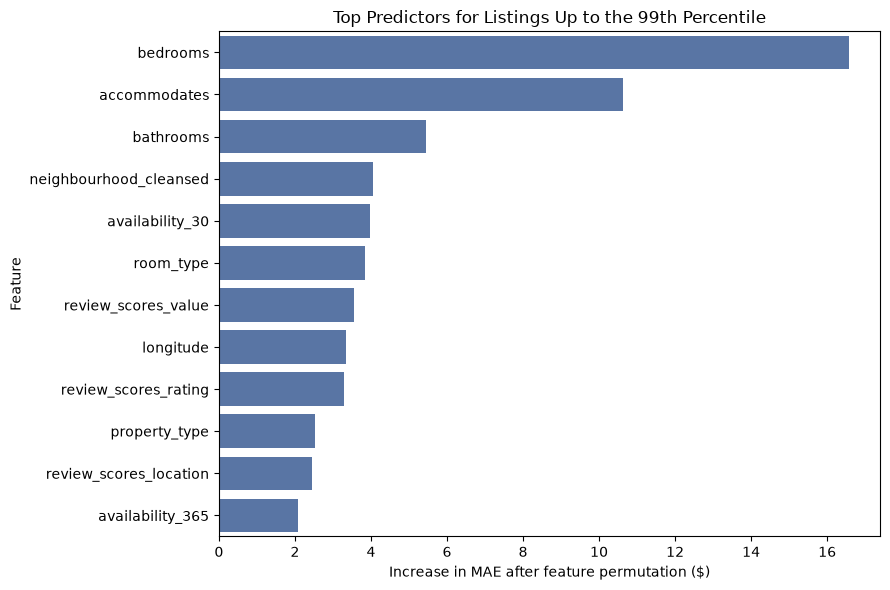

In [23]:
from sklearn.inspection import permutation_importance


typical_validation_mask = (
    y_valid <= outlier_threshold
)

X_valid_typical = X_valid.loc[
    typical_validation_mask
]

y_valid_typical = y_valid.loc[
    typical_validation_mask
]

permutation_results = permutation_importance(
    tuned_gradient_boosting_model,
    X_valid_typical,
    y_valid_typical,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "feature": X_valid.columns,
    "MAE_increase": permutation_results.importances_mean,
    "importance_std": permutation_results.importances_std
})

feature_importance = (
    feature_importance
    .sort_values("MAE_increase", ascending=False)
    .reset_index(drop=True)
)

top_features = feature_importance.head(12)

display(top_features.round(2))

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_features,
    x="MAE_increase",
    y="feature",
    color="#4C72B0"
)

plt.title(
    "Top Predictors for Listings Up to the 99th Percentile"
)
plt.xlabel("Increase in MAE after feature permutation ($)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(
    "../images/feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

Listing capacity was the strongest source of predictive information. Shuffling bedrooms increased MAE by $16.56, while shuffling accommodates increased it by $10.64 and bathrooms by $5.46. Location and listing format were also influential: neighbourhood, longitude, room type and property type all contributed to predictive accuracy. Availability and review measures provided additional information, although their individual effects were smaller. These results measure predictive importance rather than causation. Correlated features, such as bedrooms and accommodates or neighbourhood and longitude, may divide importance between themselves, so the values should not be interpreted as independent price effects.

### 3.9 Final Model and Competition Predictions

In [24]:
from pathlib import Path

# Refit the selected model using all 7,000 labelled records
final_model = clone(
    tuning_search.best_estimator_
)

final_model.fit(X, y)

competition_predictions = np.maximum(
    final_model.predict(X_competition_test),
    0
)

final_submission = sample_submission.copy()
final_submission["price"] = competition_predictions

# Validate the output
assert len(final_submission) == len(X_competition_test)
assert final_submission["price"].notna().all()
assert (final_submission["price"] >= 0).all()

output_directory = Path("../outputs")
output_directory.mkdir(exist_ok=True)

output_path = (
    output_directory
    / "airbnb_price_predictions.csv"
)

final_submission.to_csv(
    output_path,
    index=False
)

print("Submission shape:", final_submission.shape)
print("Missing predictions:", final_submission["price"].isna().sum())
print("Minimum prediction:", round(final_submission["price"].min(), 2))
print("Median prediction:", round(final_submission["price"].median(), 2))
print("Maximum prediction:", round(final_submission["price"].max(), 2))
print("Saved to:", output_path)

display(final_submission.head())

Submission shape: (3000, 2)
Missing predictions: 0
Minimum prediction: 40.69
Median prediction: 179.26
Maximum prediction: 956.59
Saved to: ..\outputs\airbnb_price_predictions.csv


,ID,price
0,7000,174.734267
1,7001,148.811323
2,7002,89.887675
3,7003,152.393903
4,7004,164.326839


## Final Results and Limitations

The tuned log-target Gradient Boosting model achieved a validation MAE of $144.10, compared with $198.88 for the median baseline—a reduction of approximately 27.5%. Ridge Regression and Random Forest achieved validation MAEs of $159.30 and $150.20 respectively. Across five cross-validation folds, Gradient Boosting also produced the lowest mean MAE at $112.81 before tuning and $111.52 after tuning.

Hyperparameter tuning improved the holdout MAE by only $0.43 compared with the untuned Gradient Boosting model. This is too small to treat as a substantial practical improvement and indicates that the choice of model family and preprocessing approach contributed more than the final tuning step.

Performance differed considerably by price range. The tuned model achieved an MAE of $48.33 across the 1,389 validation listings priced at or below approximately $1,106. Six listings priced above $2,000 accounted for 64.89% of total absolute error. The final competition predictions ranged from $40.69 to $956.59, suggesting that the model is designed primarily for mainstream listings and is unlikely to represent the extreme-price segment reliably.

Permutation importance indicated that bedrooms, guest capacity and bathrooms were the strongest predictors, followed by neighbourhood, room type, availability, review measures and longitude. These relationships are predictive rather than causal and may be shared between correlated features.

### Limitations

* The exceptionally high target values could not be verified as genuine luxury prices or data-entry errors, so they were retained in the primary evaluation.
* The validation set was examined during preliminary model comparison; consequently, its final MAE should be described as a held-out validation result rather than a completely untouched external test result.
* Competition test labels are unavailable, so the generated prediction file does not provide an independently verified test score.
* The model captures relationships within the supplied historical Melbourne listing data and may not generalise to newer market conditions, other cities or rare luxury properties.
* Free-text content was represented through word counts rather than full natural-language analysis.
* Feature importance identifies useful predictors but does not show that changing a feature would cause a change in price.

A stronger production evaluation would use newer externally labelled listings, repeated testing across different time periods and a separate modelling strategy for exceptionally expensive properties.